In [1]:
import zipfile

with zipfile.ZipFile('/content/archive (8).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/resume_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

for root, dirs, files in os.walk('/content/resume_dataset'):
    for file in files:
        print(os.path.join(root, file))

/content/resume_dataset/Resume/Resume.csv
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/41344156.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/15297298.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/10247517.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/20408458.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/27485716.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/29075857.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/70089206.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/29975124.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/92069209.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/27770859.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/16899268.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/52618188.pdf
/content/resume_dataset/data/data/INFORMATION-TECHNOLOGY/11580408.pdf
/content/resume_dataset/data/data/INFORMATION-TE

In [3]:
import os

categories = os.listdir('/content/resume_dataset/data/data')

print("Total Categories:", len(categories))
print(categories)

Total Categories: 24
['INFORMATION-TECHNOLOGY', 'CONSTRUCTION', 'HR', 'PUBLIC-RELATIONS', 'ACCOUNTANT', 'FITNESS', 'APPAREL', 'BUSINESS-DEVELOPMENT', 'AUTOMOBILE', 'AGRICULTURE', 'ARTS', 'CONSULTANT', 'ENGINEERING', 'BANKING', 'DIGITAL-MEDIA', 'ADVOCATE', 'DESIGNER', 'SALES', 'AVIATION', 'CHEF', 'BPO', 'FINANCE', 'HEALTHCARE', 'TEACHER']


In [5]:
import os

base_path = '/content/resume_dataset/data/data'

for category in os.listdir(base_path):
    files = os.listdir(os.path.join(base_path, category))
    print(category, ":", len(files))

INFORMATION-TECHNOLOGY : 120
CONSTRUCTION : 112
HR : 110
PUBLIC-RELATIONS : 111
ACCOUNTANT : 118
FITNESS : 117
APPAREL : 97
BUSINESS-DEVELOPMENT : 120
AUTOMOBILE : 36
AGRICULTURE : 63
ARTS : 103
CONSULTANT : 115
ENGINEERING : 118
BANKING : 115
DIGITAL-MEDIA : 96
ADVOCATE : 118
DESIGNER : 107
SALES : 116
AVIATION : 117
CHEF : 118
BPO : 22
FINANCE : 118
HEALTHCARE : 115
TEACHER : 102


In [6]:
!pip install pdfplumber
!pip install nltk
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 98.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [7]:
import pdfplumber
import pandas as pd
import numpy as np
import nltk
import re
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [9]:
import pdfplumber
import os

base_path = '/content/resume_dataset/data/data'

resumes = []
categories = []

for category in os.listdir(base_path):

    category_path = os.path.join(base_path, category)

    for file in os.listdir(category_path)[:20]:

        if file.endswith('.pdf'):

            pdf_path = os.path.join(category_path, file)

            try:
                text = ""

                with pdfplumber.open(pdf_path) as pdf:

                    for page in pdf.pages:

                        extracted_text = page.extract_text()

                        if extracted_text:
                            text += extracted_text

                resumes.append(text)
                categories.append(category)

            except:
                pass

print("Total resumes extracted:", len(resumes))

Total resumes extracted: 474


In [10]:
df = pd.DataFrame({
    'Category': categories,
    'Resume_Text': resumes
})

df.head()


,Category,Resume_Text
0,INFORMATION-TECHNOLOGY,VP OF INFORMATION TECHNOLOGY\nExecutive Profil...
1,INFORMATION-TECHNOLOGY,PRACTICE MANAGER\nExecutive Summary\nStrategic...
2,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY MANAGER\nProfessional S...
3,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY SUPPORT SPECIALISTNETWO...
4,INFORMATION-TECHNOLOGY,CORPORATE PROJECT MANAGER\nCareer Overview\nSe...


In [11]:
print("Shape:", df.shape)

df.info()

Shape: (474, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Category     474 non-null    object
 1   Resume_Text  474 non-null    object
dtypes: object(2)
memory usage: 7.5+ KB


In [12]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,20
CONSTRUCTION,20
HR,20
PUBLIC-RELATIONS,20
ACCOUNTANT,20
FITNESS,20
APPAREL,20
BUSINESS-DEVELOPMENT,20
AUTOMOBILE,20


In [13]:
df.sample(1)['Resume_Text'].iloc[0][:1000]

"LICENSED HEALTHCARE COMMUNICATOR\nSummary\nTo obtain a stable and growth-oriented position which will allow me to promote the profession of nursing by training and developing current and\nfuture nurses.\nExperience\n10/2016 to Current\nLicensed Healthcare Communicator Company Name ï¼\u200b City , State\nRepresenting clients on a variety of projects via inbound/outbound telecommunication which includes:.\nProviding drug product information.\nIdentify adverse events and product complaints as outlined by client guidelines.\nProvide patient education on prescribed treatment regimen.\nProvide patient support to patients enrolled in Patient Support Programs.\nAssist in training new employees, including presenting educational material, quality monitoring, and coaching and feedback.\n02/2016 to 10/2016\nRN - OR Company Name ï¼\u200b City , State\nMaintain a safe and sterile environment for the patient in the operating room.\nAnticipate the needs of the surgical staff Monitor clients' conditio

In [14]:
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words('english'))

def clean_resume(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove Emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove Numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove Special Characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove Extra Spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove Stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [15]:
df['Clean_Resume'] = df['Resume_Text'].apply(clean_resume)

df[['Category','Clean_Resume']].head()

,Category,Clean_Resume
0,INFORMATION-TECHNOLOGY,vp information technology executive profile re...
1,INFORMATION-TECHNOLOGY,practice manager executive summary strategic m...
2,INFORMATION-TECHNOLOGY,information technology manager professional su...
3,INFORMATION-TECHNOLOGY,information technology support specialistnetwo...
4,INFORMATION-TECHNOLOGY,corporate project manager career overview seas...


In [16]:
print("ORIGINAL RESUME:\n")
print(df['Resume_Text'].iloc[0][:1000])

print("\n\n" + "="*80 + "\n")

print("CLEANED RESUME:\n")
print(df['Clean_Resume'].iloc[0][:1000])

ORIGINAL RESUME:

VP OF INFORMATION TECHNOLOGY
Executive Profile
A results oriented technology leader with over 18 years of IT experience, 8 years of supervisory experience. Passionate about collaborating with
key stakeholders to develop information technology vision and strategy by effectively building organization, processes, infrastructure and services in
support of short and long-term business needs. Understands the business value of available tools and applications as to provide optimal strategic
benefit at the appropriate cost.
Skill Highlights
IT Governance Contract Negotiations
Team Leadership Disaster Recovery Plans
Systems Integration IT Operations
Core Accomplishments
Implemented a new phone system that will immediately save the company over $100,000 a year with benefits that have increased
productivity while lowering the need of IT support.Â This includes vendor contract negotiation, which resulted in the cost of the new phone
system to be covered with no out of pocket expe

In [18]:
skills = [
    'python',
    'java',
    'c++',
    'sql',
    'machine learning',
    'deep learning',
    'data analysis',
    'data science',
    'tensorflow',
    'pytorch',
    'nlp',
    'excel',
    'power bi',
    'tableau',
    'aws',
    'azure',
    'docker',
    'kubernetes',
    'git',
    'linux',
    'html',
    'css',
    'javascript',
    'react',
    'mongodb',
    'mysql'
]

In [19]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

In [20]:
df['Extracted_Skills'] = df['Clean_Resume'].apply(extract_skills)

df[['Category','Extracted_Skills']].head()

,Category,Extracted_Skills
0,INFORMATION-TECHNOLOGY,"[sql, data analysis, git]"
1,INFORMATION-TECHNOLOGY,[excel]
2,INFORMATION-TECHNOLOGY,"[sql, excel]"
3,INFORMATION-TECHNOLOGY,[excel]
4,INFORMATION-TECHNOLOGY,[]


In [21]:
df[['Category','Extracted_Skills']].sample(10)

,Category,Extracted_Skills
469,TEACHER,[excel]
277,DIGITAL-MEDIA,"[sql, excel, git, html, css]"
396,CHEF,[]
64,PUBLIC-RELATIONS,"[excel, git]"
370,AVIATION,[excel]
213,ARTS,[]
465,TEACHER,[excel]
158,BUSINESS-DEVELOPMENT,"[excel, aws]"
53,HR,[excel]
59,HR,"[data analysis, excel]"


In [22]:
job_description = """
Looking for a Data Scientist with experience in Python,
Machine Learning, SQL, Data Analysis, Git,
TensorFlow and NLP.
"""

print(job_description)


Looking for a Data Scientist with experience in Python,
Machine Learning, SQL, Data Analysis, Git,
TensorFlow and NLP.



In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = df['Clean_Resume'].tolist()

documents.append(job_description)

tfidf = TfidfVectorizer(max_features=5000)

tfidf_matrix = tfidf.fit_transform(documents)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (475, 5000)


In [24]:
job_vector = tfidf_matrix[-1]

resume_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
)

df['Match_Score'] = similarity_scores

df[['Category','Match_Score']].head()

,Category,Match_Score
0,INFORMATION-TECHNOLOGY,0.084221
1,INFORMATION-TECHNOLOGY,0.004242
2,INFORMATION-TECHNOLOGY,0.034223
3,INFORMATION-TECHNOLOGY,0.048060
4,INFORMATION-TECHNOLOGY,0.019695


In [25]:
top_candidates = df.sort_values(
    by='Match_Score',
    ascending=False
)

top_candidates[
    ['Category','Match_Score','Extracted_Skills']
].head(10)

,Category,Match_Score,Extracted_Skills
233,CONSULTANT,0.331791,"[python, java, sql, machine learning, data ana..."
287,DIGITAL-MEDIA,0.226846,"[python, java, sql, excel, power bi, tableau, ..."
14,INFORMATION-TECHNOLOGY,0.162785,"[python, java, sql, excel]"
237,ENGINEERING,0.134581,"[python, sql, git, linux, mongodb]"
7,INFORMATION-TECHNOLOGY,0.131778,"[sql, excel, html]"
140,BUSINESS-DEVELOPMENT,0.124143,"[python, sql, excel]"
247,ENGINEERING,0.100490,"[python, java, sql, aws, git, html, css, javas..."
15,INFORMATION-TECHNOLOGY,0.098270,"[sql, excel, aws, linux, mysql]"
412,BPO,0.097132,"[java, sql, excel]"
455,TEACHER,0.095748,[excel]


In [26]:
required_skills = [
    'python',
    'machine learning',
    'sql',
    'data analysis',
    'git',
    'tensorflow',
    'nlp'
]

def skill_gap(candidate_skills):
    return list(set(required_skills) - set(candidate_skills))

df['Missing_Skills'] = df['Extracted_Skills'].apply(skill_gap)

df[['Extracted_Skills','Missing_Skills']].head()

,Extracted_Skills,Missing_Skills
0,"[sql, data analysis, git]","[machine learning, tensorflow, python, nlp]"
1,[excel],"[machine learning, python, tensorflow, data an..."
2,"[sql, excel]","[machine learning, python, tensorflow, data an..."
3,[excel],"[machine learning, python, tensorflow, data an..."
4,[],"[machine learning, python, data analysis, git,..."


In [27]:
top_candidate = df.sort_values(
    by='Match_Score',
    ascending=False
).iloc[0]

print("Category:")
print(top_candidate['Category'])

print("\nSkills Found:")
print(top_candidate['Extracted_Skills'])

print("\nMissing Skills:")
print(top_candidate['Missing_Skills'])

Category:
CONSULTANT

Skills Found:
['python', 'java', 'sql', 'machine learning', 'data analysis', 'data science', 'azure', 'javascript', 'mysql']

Missing Skills:
['git', 'tensorflow', 'nlp']


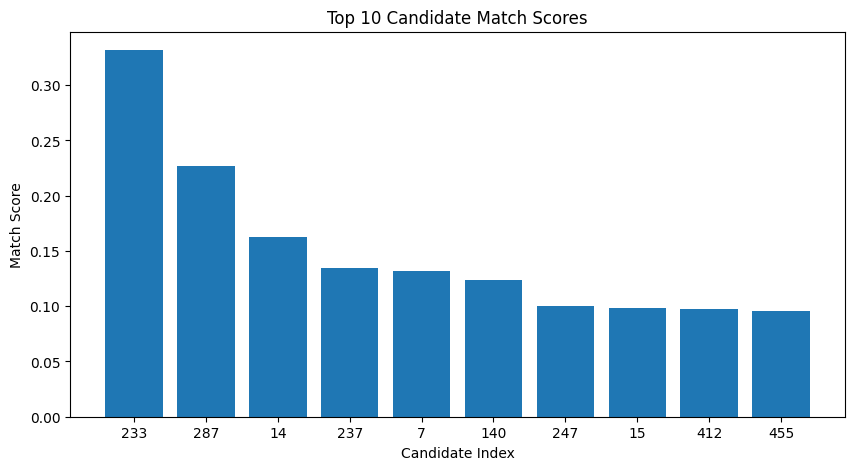

In [28]:
import matplotlib.pyplot as plt

top10 = df.sort_values(
    by='Match_Score',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10.index.astype(str),
    top10['Match_Score']
)

plt.title('Top 10 Candidate Match Scores')
plt.xlabel('Candidate Index')
plt.ylabel('Match Score')

plt.show()

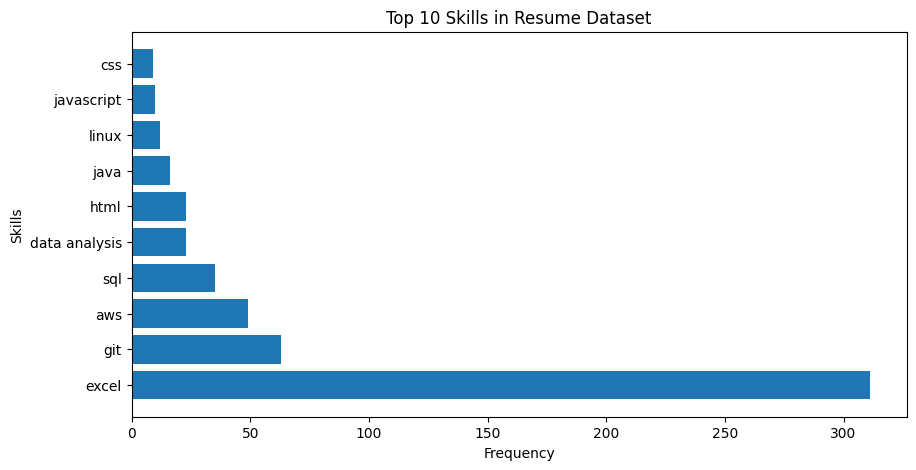

In [29]:
from collections import Counter
import matplotlib.pyplot as plt

all_skills = []

for skills in df['Extracted_Skills']:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(10)

skills = [x[0] for x in top_skills]
counts = [x[1] for x in top_skills]

plt.figure(figsize=(10,5))
plt.barh(skills, counts)

plt.title("Top 10 Skills in Resume Dataset")
plt.xlabel("Frequency")
plt.ylabel("Skills")

plt.show()

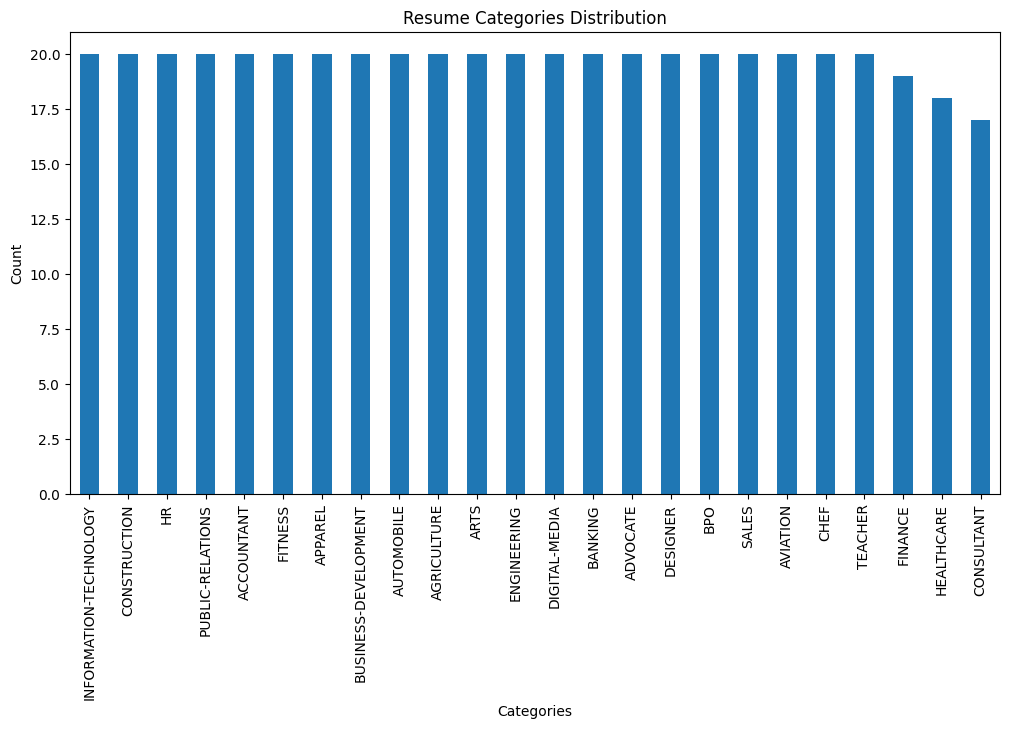

In [30]:
plt.figure(figsize=(12,6))

df['Category'].value_counts().plot(
    kind='bar'
)

plt.title("Resume Categories Distribution")
plt.xlabel("Categories")
plt.ylabel("Count")

plt.show()

In [31]:
top_candidates.to_csv(
    "ranked_candidates.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully
